Diabetes Dataset Decision Tree

In [1]:
print("Hello world")

Hello world


In [2]:
import pandas as pd

In [ ]:
# Age is in a differen scale than estimated salary. Thus we need to convert them into a standard scale.

In [3]:
df = pd.read_csv("/home/msis/ahegde/aml-lab/projects/data/diabetes.csv")

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
x = df.iloc[:,1:5].values
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [9]:
y = df.iloc[:, -1].values
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
import numpy as np

In [11]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=45)

In [13]:
x_test

array([[5.1, 3.5, 1.4, 0.2],
       [5. , 3.5, 1.6, 0.6],
       [7.2, 3. , 5.8, 1.6],
       [4.6, 3.1, 1.5, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.1, 3.8, 1.9, 0.4],
       [4.4, 3. , 1.3, 0.2],
       [7.6, 3. , 6.6, 2.1],
       [6.3, 2.7, 4.9, 1.8],
       [6.7, 3.1, 5.6, 2.4],
       [5.2, 3.4, 1.4, 0.2],
       [7.2, 3.2, 6. , 1.8],
       [5.7, 2.5, 5. , 2. ],
       [6.3, 2.9, 5.6, 1.8],
       [6.3, 2.8, 5.1, 1.5],
       [5. , 3.2, 1.2, 0.2],
       [6.7, 3. , 5.2, 2.3],
       [5.8, 2.7, 5.1, 1.9],
       [5. , 3.5, 1.3, 0.3],
       [6.3, 2.3, 4.4, 1.3],
       [5.4, 3. , 4.5, 1.5],
       [6. , 3.4, 4.5, 1.6],
       [6.4, 3.2, 5.3, 2.3],
       [6.4, 3.2, 4.5, 1.5],
       [5. , 3.6, 1.4, 0.2],
       [6.8, 3. , 5.5, 2.1],
       [5.8, 2.6, 4. , 1.2],
       [5.6, 2.9, 3.6, 1.3],
       [5.4, 3.7, 1.5, 0.2],
       [6.1, 3. , 4.6, 1.4]])

In [14]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

In [15]:
x_train

array([[ 1.15648738, -0.54035544,  0.59307474,  0.26928484],
       [-0.17327163, -0.31829156,  0.24870876,  0.13684967],
       [ 0.18938992, -1.87273871,  0.70786339,  0.40172   ],
       [-0.05238445, -0.76241932,  0.76525772,  0.93146067],
       [-1.01948191, -0.09622768, -1.2435438 , -1.31993715],
       [ 0.67293865,  0.1258362 ,  0.99483504,  0.7990255 ],
       [-1.86569218, -0.09622768, -1.53051545, -1.45237232],
       [-1.01948191,  0.79202784, -1.2435438 , -1.05506682],
       [ 0.67293865, -0.31829156,  0.30610309,  0.13684967],
       [-1.26125627,  0.1258362 , -1.2435438 , -1.31993715],
       [-0.41504599,  2.56853887, -1.35833246, -1.31993715],
       [-0.05238445, -0.76241932,  0.07652577,  0.00441451],
       [-1.14036909, -0.09622768, -1.35833246, -1.31993715],
       [ 1.27737456,  0.1258362 ,  0.65046907,  0.40172   ],
       [-1.01948191, -1.65067484, -0.2678402 , -0.26045583],
       [-0.89859472,  1.45821947, -1.30093813, -1.05506682],
       [ 0.67293865, -0.

In [16]:
x_test

array([[-0.89859472,  1.01409172, -1.35833246, -1.31993715],
       [-1.01948191,  1.01409172, -1.2435438 , -0.79019649],
       [ 1.64003611, -0.09622768,  1.16701803,  0.53415517],
       [-1.50303064,  0.1258362 , -1.30093813, -1.31993715],
       [-1.14036909,  0.1258362 , -1.30093813, -1.45237232],
       [-0.89859472,  1.68028335, -1.07136081, -1.05506682],
       [-1.744805  , -0.09622768, -1.41572679, -1.31993715],
       [ 2.12358484, -0.09622768,  1.62617266,  1.196331  ],
       [ 0.55205147, -0.76241932,  0.65046907,  0.7990255 ],
       [ 1.0356002 ,  0.1258362 ,  1.05222937,  1.5936365 ],
       [-0.77770754,  0.79202784, -1.35833246, -1.31993715],
       [ 1.64003611,  0.34790008,  1.28180669,  0.7990255 ],
       [-0.17327163, -1.20654708,  0.70786339,  1.06389583],
       [ 0.55205147, -0.31829156,  1.05222937,  0.7990255 ],
       [ 0.55205147, -0.54035544,  0.76525772,  0.40172   ],
       [-1.01948191,  0.34790008, -1.47312112, -1.31993715],
       [ 1.0356002 , -0.

In [19]:
y_train

array([0, 0, 2, 2, 1, 2, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 2, 0, 2, 1, 1, 0,
       2, 1, 2, 1, 1, 0, 1, 0, 0, 2, 0, 2, 1, 1, 1, 1, 0, 1, 0, 2, 0, 0,
       0, 1, 1, 0, 1, 0, 2, 2, 2, 0, 0, 2, 0, 1, 0, 0, 0, 2, 0, 0, 2, 0,
       0, 2, 2, 2, 1, 1, 0, 2, 2, 2, 1, 0, 2, 0, 0, 0, 1, 2, 2, 1, 1, 2,
       1, 2, 0, 0, 2, 2, 0, 1, 1, 2, 1, 0, 2, 2, 1, 1, 1, 2, 1, 1, 2, 0,
       0, 0, 1, 2, 2, 0, 0, 1, 2, 2])

In [17]:
from sklearn import tree
#clf = tree.DecisionTreeClassifier(criterion='entropy', random_state=0)
clf = tree.DecisionTreeClassifier(criterion='gini')

In [20]:
clf.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
y_pred = clf.predict(x_test)

In [22]:
y_pred

array([1, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 0, 0, 0,
       2, 0, 1, 2, 0, 0, 1, 0])

In [23]:
from sklearn.metrics import confusion_matrix

In [24]:
confusion_matrix(y_test, y_pred)

array([[ 7,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 12]])

In [25]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy = accuracy_score(y_test, y_pred)*100

In [30]:
accuracy

100.0

[Text(0.5416666666666666, 0.9285714285714286, 'x[3] <= -0.592\ngini = 0.666\nsamples = 120\nvalue = [43, 39, 38]'),
 Text(0.4583333333333333, 0.7857142857142857, 'gini = 0.0\nsamples = 39\nvalue = [0, 39, 0]'),
 Text(0.5, 0.8571428571428572, 'True  '),
 Text(0.625, 0.7857142857142857, 'x[3] <= 0.733\ngini = 0.498\nsamples = 81\nvalue = [43, 0, 38]'),
 Text(0.5833333333333333, 0.8571428571428572, '  False'),
 Text(0.4166666666666667, 0.6428571428571429, 'x[2] <= 0.909\ngini = 0.124\nsamples = 45\nvalue = [42, 0, 3]'),
 Text(0.3333333333333333, 0.5, 'x[0] <= -1.08\ngini = 0.087\nsamples = 44\nvalue = [42, 0, 2]'),
 Text(0.16666666666666666, 0.35714285714285715, 'x[2] <= 0.077\ngini = 0.5\nsamples = 2\nvalue = [1, 0, 1]'),
 Text(0.08333333333333333, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0]'),
 Text(0.25, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.5, 0.35714285714285715, 'x[2] <= 0.679\ngini = 0.046\nsamples = 42\nvalue = [41, 0, 1]'

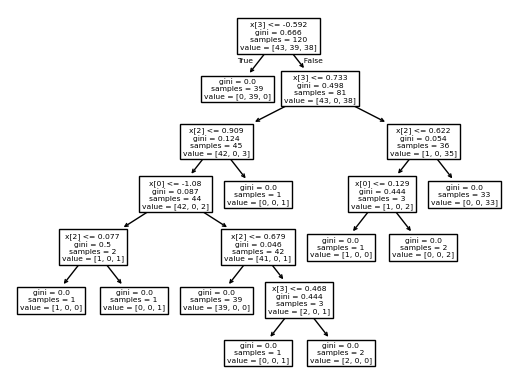

In [32]:
from sklearn import tree
tree.plot_tree(clf)